<a href="https://colab.research.google.com/github/Ravali0708/Leak-Watch---Machine-Learning-for-Water-Leak-Detection-Localization-and-Emergency-Dispatch/blob/main/MS_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wntr pandas scikit-learn matplotlib networkx

In [3]:
import wntr
import pandas
import sklearn
import matplotlib
import networkx
print(" ready!")
print("wntr version:", wntr.__version__)

 ready!
wntr version: 1.5.0


## Step 1: Generating the sensor data by simulation
I create my own leak data using the EPANET water simulator (through WNTR).
I load a water network, add a leak, and record the pressure at each sensor.

Loaded network with 117 pipes and 92 junctions.
Leak added at node 111
Simulation finished.
Saved 577 rows to my_sensor_readings.csv
       hour  pressure_101  pressure_103  pressure_105  pressure_107  \
0  0.000000     31.553927     31.239680     36.066800     38.046030   
1  0.083333     31.566533     31.252268     36.079721     38.058939   
2  0.166667     31.579177     31.264894     36.092677     38.071881   
3  0.250000     31.591865     31.277563     36.105672     38.084864   
4  0.333333     31.604591     31.290271     36.118701     38.097880   

   pressure_109  pressure_111  pressure_125  pressure_163  pressure_203  \
0     38.158801     41.486071     45.545523     43.898148     42.041482   
1     38.171383     41.498458     45.563124     43.910826     42.046269   
2     38.184004     41.510885     45.580703     43.923545     42.051284   
3     38.196669     41.523359     45.598263     43.936311     42.056539   
4     38.209372     41.535874     45.615803     43.949117     42.

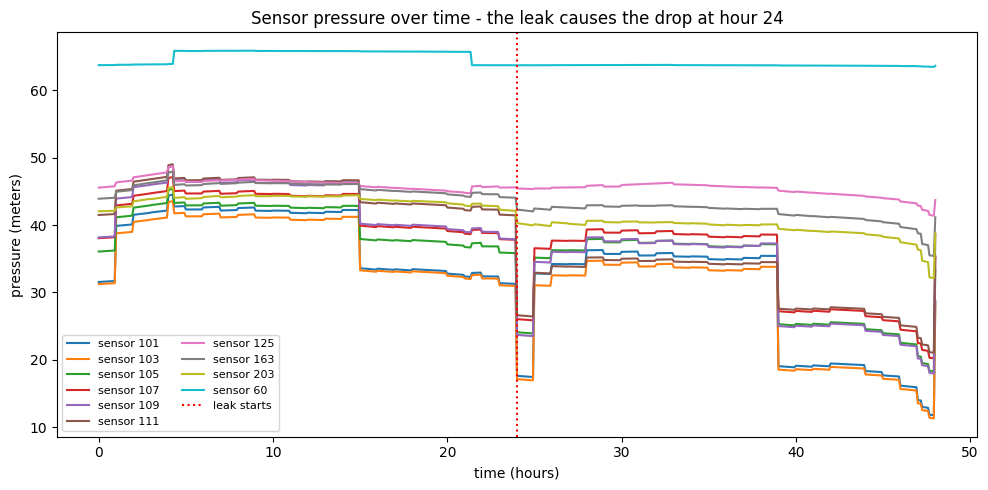

Done!


In [ ]:
import os       # finds files on the computer
import wntr       # the water simulator (runs EPANET)
import pandas       # tool for making data tables
import matplotlib.pyplot as plt   # tool for drawing charts


# 1.find the network file that comes with WNTR
wntr_folder = os.path.dirname(wntr.__file__)       # find the folder where WNTR is installed
inp_file = os.path.join(wntr_folder, "library", "networks", "Net3.inp")   #build the path to net3 network file

# load the network pi[es and junctions
wn = wntr.network.WaterNetworkModel(inp_file)
number_of_pipes = len(wn.pipe_name_list)     #count of pipes
number_of_junctions = len(wn.junction_name_list)  #count fo junctions
print("Loaded network with", number_of_pipes, "pipes and", number_of_junctions, "junctions.")   # shows the result

#  2. set how long to simulate and how often to take a reading
wn.options.time.duration = 48 * 3600
wn.options.time.hydraulic_timestep = 300
wn.options.time.report_timestep = 300

#  3. choose the sensors- the junctions we treat as pressure sensors
sensors = ["101", "103", "105", "107", "109", "111", "125", "163", "203", "60"]

#  4. add a leak at one junction
leak_node = "111"   # i put the leak junction at 111
node_object = wn.get_node(leak_node)     # grab that junction from the network
node_object.add_leak(wn, area=0.02, start_time=24 * 3600, end_time=48 * 3600)     # open a hole
print("Leak added at node", leak_node)

#  5. run the simulation
simulator = wntr.sim.WNTRSimulator(wn)  # create the simulator for our network
results = simulator.run_sim()           # run it - this calculates pressure everywhere, every 5 minutes ***
print("Simulation finished.")

#  6. get the pressure results, and keep only our sensor columns
all_pressure = results.node["pressure"]      #the pressure at every junction all time
sensor_pressure = all_pressure[sensors]       # keep only the columns for our chosen sensors


# the results are timed in seconds; change them to hours
list_of_hours = []       # make an empty list to hold the times in hours
for seconds in sensor_pressure.index:
    hours = seconds / 3600.0
    list_of_hours.append(hours)

#  7. build the table one column at a time
table = pandas.DataFrame()      # make an empty table
table["hour"] = list_of_hours    #adds the hour column

for sensor_name in sensors:         #go through each sensor one by one
    column_name = "pressure_" + sensor_name
    sensor_values = list(sensor_pressure[sensor_name])
    table[column_name] = sensor_values

# make the leak label: 1 when the leak is on (hour 24 or later), else 0
leak_label = []
for hour in list_of_hours:
    if hour >= 24:             # if the leak has started (hour 24 or later)
        leak_label.append(1)       # write 1  (leak is happening)
    else:
        leak_label.append(0)        # write 0  (no leak yet)
table["leak_active"] = leak_label    # add the leak answer as a column
table["leak_node"] = leak_node       # also record which node the leak is at

#  8. save the table to a CSV file
table.to_csv("my_sensor_readings.csv", index=False)
print("Saved", len(table), "rows to my_sensor_readings.csv")
print(table.head())

#  9. draw the chart
plt.figure(figsize=(10, 5))      # start a new chart, set its size
for sensor_name in sensors:       #each sensor
    column_name = "pressure_" + sensor_name
    plt.plot(table["hour"], table[column_name], label="sensor " + sensor_name)      #draw its line time vs pressure

plt.axvline(24, color="red", linestyle=":", label="leak starts")     # drwa a red dot line at 24 hours
plt.title("Sensor pressure over time - the leak causes the drop at hour 24")   # title of chart
plt.xlabel("time (hours)")     #lables of x-axis
plt.ylabel("pressure (meters)")  #lables of y-axis
plt.legend(fontsize=8, ncol=2)     # show which line is which sensor
plt.tight_layout()              # tidy the spacing
plt.savefig("my_sensor_chart.png")   # saves the chart image
plt.show()                          # show the chart on screen
print("Done!")